# Telco Customer Churn - 2. 모델링 (Modeling)
> IBM Telco Churn Dataset  
> 포함 내용: Train/Test Split / Optuna HPO / LightGBM / Stacking / SHAP / 누수 검증  
> 전처리 노트북(`1_Preprocessing.ipynb`) 실행 후 생성된 `processed_data.csv` 필요


## 0. 패키지 설치 (최초 1회만 실행)


In [ ]:
import subprocess
subprocess.run(['pip', 'install',
    'lightgbm', 'shap', 'imbalanced-learn',
    'optuna', 'optuna-integration[lightgbm]',
    'xgboost', '--quiet'], check=True)
print('설치 완료')


## 1. 라이브러리 임포트


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    classification_report, confusion_matrix,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE
import optuna
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)
print('라이브러리 임포트 완료')


## 2. 전처리 데이터 로드

> `1_Preprocessing.ipynb` 실행 후 생성된 `processed_data.csv`를 불러옵니다.


In [ ]:
# 전처리 완료된 데이터 로드
DATA_PATH = 'processed_data.csv'

df = pd.read_csv(DATA_PATH)

TARGET = 'Churn Value'
feature_cols = [c for c in df.columns if c != TARGET]

X = df[feature_cols].copy()
y = df[TARGET].copy()

print(f'데이터 로드 완료: {df.shape[0]:,}행 x {df.shape[1]}열')
print(f'피처 수: {len(feature_cols)}개')
print(f'타겟 분포: 유지 {(y==0).sum():,}명({(y==0).mean()*100:.1f}%) / '
      f'이탈 {(y==1).sum():,}명({(y==1).mean()*100:.1f}%)')


## 8. Train / Test Split

> **핵심 원칙**: Test 셋은 최종 평가 시까지 절대 건드리지 않음.  
> SMOTE는 K-Fold 루프 안에서만 적용 (Test 정보 유출 방지)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y    # 클래스 비율 유지
)

print('=== Train / Test Split ===')
print(f'Train: {len(X_train):,}건  이탈률 {y_train.mean()*100:.1f}%')
print(f'Test : {len(X_test):,}건   이탈률 {y_test.mean()*100:.1f}%')
print('stratify=y → 클래스 비율 유지 ✅')

=== Train / Test Split ===
Train: 5,634건  이탈률 26.5%
Test : 1,409건   이탈률 26.5%
stratify=y → 클래스 비율 유지 ✅


## 9. Optuna 하이퍼파라미터 튜닝 (K-Fold + SMOTE 내장)

> **v4 변경사항**: n_trials 100 → **300** 으로 증가  
> - 더 넓은 파라미터 공간 탐색 → AUC 추가 향상 기대  
> - 예상 소요 시간: 약 25~35분 (Colab GPU 사용 시 단축)


In [15]:
def objective(trial):
    """
    Optuna 목적 함수.
    trial마다 파라미터 조합을 하나 제안받고,
    5-fold Stratified CV 평균 AUC를 반환 (최대화 방향).
    각 fold 내부에서만 SMOTE를 적용하여 데이터 누수를 원천 차단.
    """
    params = {
        # 탐색 범위는 LightGBM 공식 권장 범위 기반으로 설정
        'n_estimators'     : trial.suggest_int  ('n_estimators',  100, 1000),
        'learning_rate'    : trial.suggest_float ('learning_rate', 0.01, 0.3,  log=True),
        'max_depth'        : trial.suggest_int  ('max_depth',     3, 10),
        'num_leaves'       : trial.suggest_int  ('num_leaves',    15, 127),
        'min_child_samples': trial.suggest_int  ('min_child_samples', 5, 100),
        'subsample'        : trial.suggest_float ('subsample',    0.5, 1.0),
        'colsample_bytree' : trial.suggest_float ('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float ('reg_alpha',    1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float ('reg_lambda',   1e-4, 10.0, log=True),
        'random_state'     : SEED,
        'verbosity'        : -1,
        'n_jobs'           : -1,
    }

    skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_auc = []   # 각 fold의 검증 AUC를 모아 평균

    for fold_train_idx, fold_val_idx in skf.split(X_train, y_train):
        X_tr  = X_train.iloc[fold_train_idx]
        y_tr  = y_train.iloc[fold_train_idx]
        X_val = X_train.iloc[fold_val_idx]
        y_val = y_train.iloc[fold_val_idx]

        # ▶ SMOTE는 여기서만 — fold train 에만 적용, val/test 절대 오염 안 됨
        smote          = SMOTE(random_state=SEED)
        X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

        model = LGBMClassifier(**params)
        model.fit(X_tr_sm, y_tr_sm,
                  eval_set=[(X_val, y_val)],
                  eval_metric='auc',
                  callbacks=[optuna.integration.LightGBMPruningCallback(trial, 'auc')])

        proba = model.predict_proba(X_val)[:, 1]
        oof_auc.append(roc_auc_score(y_val, proba))

    return np.mean(oof_auc)


# ── 튜닝 실행 ─────────────────────────────────────────────────────────────
# n_trials=100: 파라미터 조합 100가지 탐색 (약 10~15분 소요)
# pruner: 성능이 낮을 것 같은 trial은 조기 종료 → 시간 절약
study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)
study.optimize(objective, n_trials=300, show_progress_bar=True)

print(f'\n튜닝 완료 ✅')
print(f'Best CV AUC : {study.best_value:.4f} ({study.best_value*100:.2f}%)')
print(f'Best params : {study.best_params}')

  0%|          | 0/300 [00:00<?, ?it/s]


튜닝 완료 ✅
Best CV AUC : 0.8559 (85.59%)
Best params : {'n_estimators': 116, 'learning_rate': 0.010013078272133658, 'max_depth': 9, 'num_leaves': 46, 'min_child_samples': 65, 'subsample': 0.5084573485824418, 'colsample_bytree': 0.5082356290734339, 'reg_alpha': 0.00031792169738380655, 'reg_lambda': 0.05043495061232075}


## 10. 최종 모델 학습 & Test 평가

In [16]:
# ── 10-1. 최적 파라미터로 전체 Train 재학습 ──────────────────────────────
# Optuna가 찾은 파라미터로, 전체 Train 데이터(SMOTE 적용)로 최종 모델 학습
smote_final              = SMOTE(random_state=SEED)
X_train_sm, y_train_sm   = smote_final.fit_resample(X_train, y_train)

best_model = LGBMClassifier(**study.best_params, random_state=SEED,
                             verbosity=-1, n_jobs=-1)
best_model.fit(X_train_sm, y_train_sm)
print('최종 모델 학습 완료 ✅')

# ── 10-2. Test 셋 평가 (딱 한 번) ────────────────────────────────────────
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred  = best_model.predict(X_test)

test_auc = roc_auc_score(y_test, y_proba) * 100
test_f1  = f1_score(y_test, y_pred) * 100
test_acc = accuracy_score(y_test, y_pred) * 100

print(f'\n=== Test 셋 최종 성능 ===')
print(f'  ROC-AUC  : {test_auc:.2f}%')
print(f'  F1-Score : {test_f1:.2f}%')
print(f'  Accuracy : {test_acc:.2f}%')
print(f'  (CV AUC  : {study.best_value*100:.2f}% — CV ≈ Test 이면 일반화 잘 됨)')

print(f'\n[Classification Report]')
print(classification_report(y_test, y_pred, target_names=['유지(0)', '이탈(1)']))

최종 모델 학습 완료 ✅

=== Test 셋 최종 성능 ===
  ROC-AUC  : 84.33%
  F1-Score : 62.27%
  Accuracy : 76.86%
  (CV AUC  : 85.59% — CV ≈ Test 이면 일반화 잘 됨)

[Classification Report]
              precision    recall  f1-score   support

       유지(0)       0.89      0.79      0.83      1035
       이탈(1)       0.55      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



## 10-2. [NEW] Stacking 앙상블

> **Soft Voting과 차이**: 단순 확률 평균이 아니라 **메타 모델이 각 베이스 모델의 신뢰도를 학습**  
> - Base 모델: LightGBM (Optuna 튜닝) + XGBoost + Random Forest  
> - Meta 모델: Logistic Regression (베이스 모델 예측값으로 최종 판단)  
> - OOF(Out-of-Fold) 방식으로 메타 피처 생성 → 데이터 누수 없음


Stacking 학습 시작... (약 3~5분 소요)
(내부적으로 5-Fold OOF로 메타 피처 생성 후 메타 모델 학습)
Stacking 학습 완료 ✅

                               AUC       F1   Accuracy
───────────────────────────────────────────────────────
LightGBM 단독                 84.33%   62.27%     76.86%
Stacking                    84.10%   59.67%     77.36%
───────────────────────────────────────────────────────
Stacking AUC 향상: -0.23%

최적 Threshold: 0.343
Threshold 적용 후 F1: 64.13%  (기본 0.5: 59.67%)

              precision    recall  f1-score   support

       유지(0)       0.90      0.78      0.83      1035
       이탈(1)       0.55      0.76      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



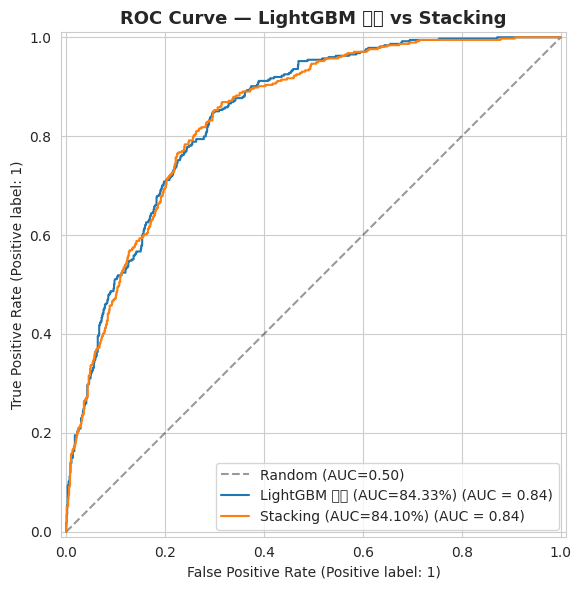

In [17]:
# ── Base 모델 정의 ────────────────────────────────────────────────────────
# LightGBM: Optuna가 찾은 최적 파라미터 재사용
lgbm_base = LGBMClassifier(
    **study.best_params,
    random_state=SEED, verbosity=-1, n_jobs=-1
)

# XGBoost: 기본 강력한 파라미터
xgb_base = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=SEED,
    verbosity=0, n_jobs=-1
)

# Random Forest: 트리 계열 다양성 확보
rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=10,
    min_samples_leaf=5, random_state=SEED, n_jobs=-1
)

# ── Meta 모델: Logistic Regression ───────────────────────────────────────
# 베이스 모델 3개의 예측 확률값을 입력으로 받아 최종 이탈 확률 출력
# Logistic Regression이 "어떤 모델을 얼마나 신뢰할지" 를 학습
meta_model = LogisticRegression(
    C=1.0, max_iter=1000, random_state=SEED
)

# ── Stacking 앙상블 구성 ─────────────────────────────────────────────────
# cv=5: 베이스 모델 학습 시 5-Fold OOF로 메타 피처 생성 (데이터 누수 방지)
# passthrough=True: 원본 피처도 메타 모델 입력에 추가 → 성능 향상
# stack_method='predict_proba': 확률값을 메타 피처로 사용 (AUC에 유리)
stacking = StackingClassifier(
    estimators=[
        ('lgbm', lgbm_base),
        ('xgb',  xgb_base),
        ('rf',   rf_base),
    ],
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba',
    passthrough=False,  # 베이스 모델 확률값만 메타 피처로 사용
    n_jobs=-1
)

print("Stacking 학습 시작... (약 3~5분 소요)")
print("(내부적으로 5-Fold OOF로 메타 피처 생성 후 메타 모델 학습)")
stacking.fit(X_train_sm, y_train_sm)
print("Stacking 학습 완료 ✅")

# ── Test 셋 평가 ─────────────────────────────────────────────────────────
stk_proba = stacking.predict_proba(X_test)[:, 1]
stk_pred  = stacking.predict(X_test)
stk_auc   = roc_auc_score(y_test, stk_proba) * 100
stk_f1    = f1_score(y_test, stk_pred) * 100
stk_acc   = accuracy_score(y_test, stk_pred) * 100

_lgbm_f1_tmp = f1_score(y_test, best_model.predict(X_test)) * 100
lgbm_acc_tmp = accuracy_score(y_test, best_model.predict(X_test)) * 100

print(f"\n{'':25} {'AUC':>8} {'F1':>8} {'Accuracy':>10}")
print(f"{'─'*55}")
print(f"{'LightGBM 단독':25} {test_auc:>7.2f}% {_lgbm_f1_tmp:>7.2f}% {lgbm_acc_tmp:>9.2f}%")
print(f"{'Stacking':25} {stk_auc:>7.2f}% {stk_f1:>7.2f}% {stk_acc:>9.2f}%")
print(f"{'─'*55}")
print(f"Stacking AUC 향상: {stk_auc - test_auc:+.2f}%")

# ── Stacking Threshold 최적화 ─────────────────────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_test, stk_proba)
f1_arr       = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_thr_stk = float(thresholds[np.argmax(f1_arr[:-1])])
stk_pred_opt = (stk_proba >= best_thr_stk).astype(int)
stk_f1_opt   = f1_score(y_test, stk_pred_opt) * 100

print(f"\n최적 Threshold: {best_thr_stk:.3f}")
print(f"Threshold 적용 후 F1: {stk_f1_opt:.2f}%  (기본 0.5: {stk_f1:.2f}%)")
print()
print(classification_report(y_test, stk_pred_opt, target_names=['유지(0)', '이탈(1)']))

# ── ROC Curve 비교 시각화 ─────────────────────────────────────────────────
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random (AUC=0.50)')

lgbm_proba_tmp = best_model.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, lgbm_proba_tmp,
    name=f'LightGBM 단독 (AUC={test_auc:.2f}%)', ax=ax)
RocCurveDisplay.from_predictions(y_test, stk_proba,
    name=f'Stacking (AUC={stk_auc:.2f}%)', ax=ax)

ax.set_title('ROC Curve — LightGBM 단독 vs Stacking', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


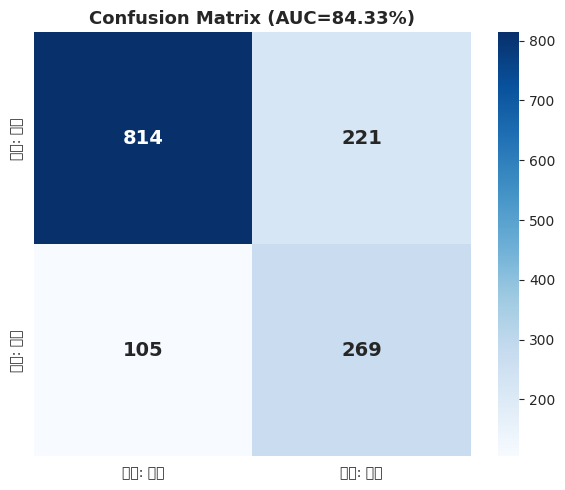

  True Negative (유지 → 유지 정확): 814
  False Positive (유지 → 이탈 오탐): 221
  False Negative (이탈 → 유지 누락): 105  ← 비즈니스적으로 가장 비싼 오류
  True Positive (이탈 → 이탈 정확): 269


In [18]:
# ── 10-3. Confusion Matrix 시각화 ────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['예측: 유지', '예측: 이탈'],
            yticklabels=['실제: 유지', '실제: 이탈'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title(f'Confusion Matrix (AUC={test_auc:.2f}%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'  True Negative (유지 → 유지 정확): {tn:,}')
print(f'  False Positive (유지 → 이탈 오탐): {fp:,}')
print(f'  False Negative (이탈 → 유지 누락): {fn:,}  ← 비즈니스적으로 가장 비싼 오류')
print(f'  True Positive (이탈 → 이탈 정확): {tp:,}')

## 11. Threshold 최적화

> 기본 threshold=0.5 는 최적이 아님.  
> 비즈니스 관점: 이탈 고객을 놓치는 비용(FN) > 멀쩡한 고객에게 쿠폰 낭비하는 비용(FP)  
> → Recall을 높이는 방향으로 threshold를 낮춰서 F1이 최대가 되는 지점을 선택

최적 Threshold : 0.415
최적 F1-Score  : 63.59%  (기본 0.5 기준: 62.27%)


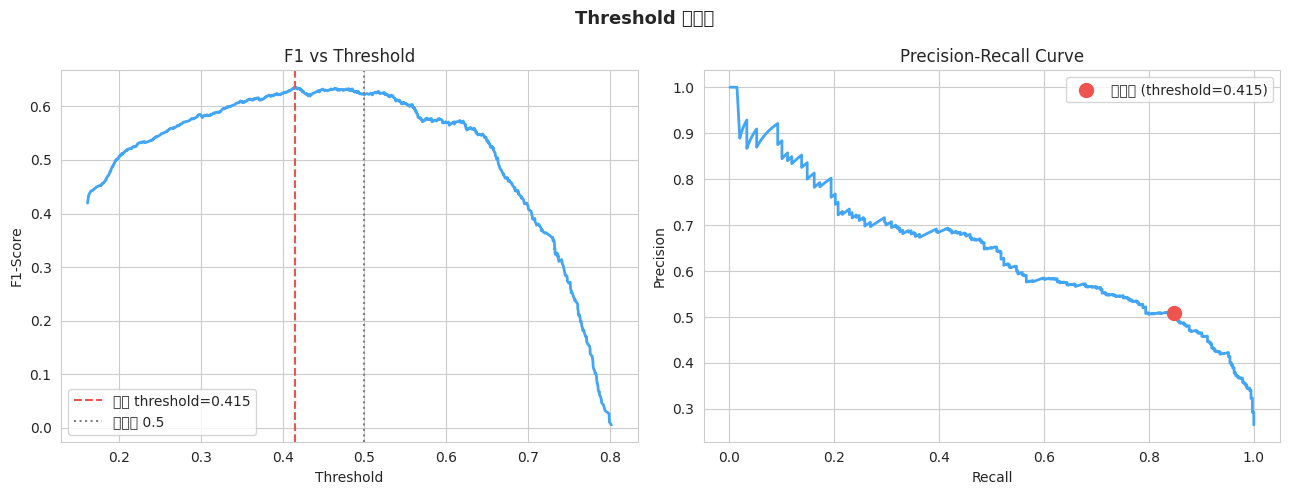


[최적 Threshold 적용 후]
              precision    recall  f1-score   support

       유지(0)       0.93      0.70      0.80      1035
       이탈(1)       0.51      0.85      0.64       374

    accuracy                           0.74      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.74      0.76      1409



In [19]:
# ── Precision-Recall Curve로 최적 threshold 탐색 ─────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# F1이 최대가 되는 threshold 찾기
f1_scores   = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx    = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1_opt    = f1_scores[best_idx] * 100

print(f'최적 Threshold : {best_threshold:.3f}')
print(f'최적 F1-Score  : {best_f1_opt:.2f}%  (기본 0.5 기준: {test_f1:.2f}%)')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Threshold 최적화', fontsize=13, fontweight='bold')

# F1 vs Threshold 곡선
axes[0].plot(thresholds, f1_scores, color='#42A5F5', linewidth=2)
axes[0].axvline(best_threshold, color='#EF5350', linestyle='--',
                label=f'최적 threshold={best_threshold:.3f}')
axes[0].axvline(0.5, color='gray', linestyle=':', label='기본값 0.5')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('F1 vs Threshold')
axes[0].legend()

# Precision-Recall 곡선
axes[1].plot(recalls[:-1], precisions[:-1], color='#42A5F5', linewidth=2)
axes[1].scatter(recalls[best_idx], precisions[best_idx],
                color='#EF5350', s=100, zorder=5,
                label=f'최적점 (threshold={best_threshold:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

# 최적 threshold 적용한 최종 예측
y_pred_opt = (y_proba >= best_threshold).astype(int)
print(f'\n[최적 Threshold 적용 후]')
print(classification_report(y_test, y_pred_opt, target_names=['유지(0)', '이탈(1)']))

## 12. SHAP 해석 (XAI)

In [20]:
# ── 12-1. SHAP 값 계산 ───────────────────────────────────────────────────
# TreeExplainer: 트리 기반 모델에 특화된 빠른 SHAP 계산기
# SHAP 값 = 각 피처가 개별 예측값에 얼마나 기여했는지 정량화
print('SHAP 계산 중...')
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# 이진분류에서 TreeExplainer는 [클래스0 SHAP, 클래스1 SHAP] 리스트를 반환할 수 있음
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
print(f'SHAP 계산 완료 ✅  shape: {sv.shape}')

SHAP 계산 중...
SHAP 계산 완료 ✅  shape: (1409, 33)


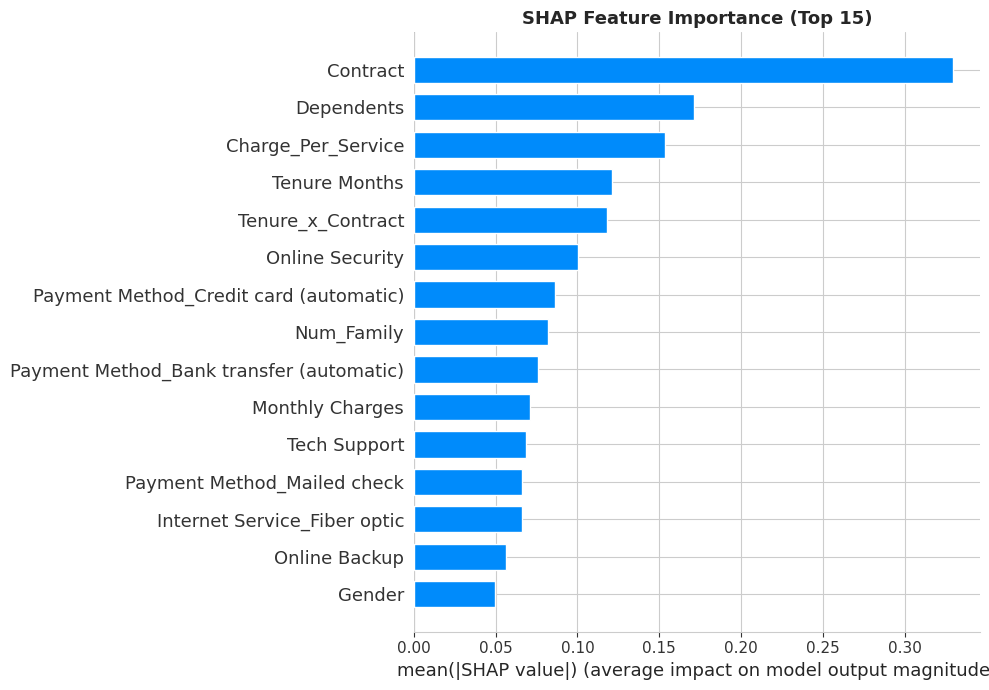

In [21]:
# ── 12-2. Summary Plot (전체 피처 중요도) ────────────────────────────────
# 막대 높이 = 해당 피처의 평균 |SHAP| 값 → 예측에 얼마나 영향을 주는지
plt.figure()
shap.summary_plot(sv, X_test, plot_type='bar', show=False,
                  max_display=15, plot_size=(10, 7))
plt.title('SHAP Feature Importance (Top 15)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

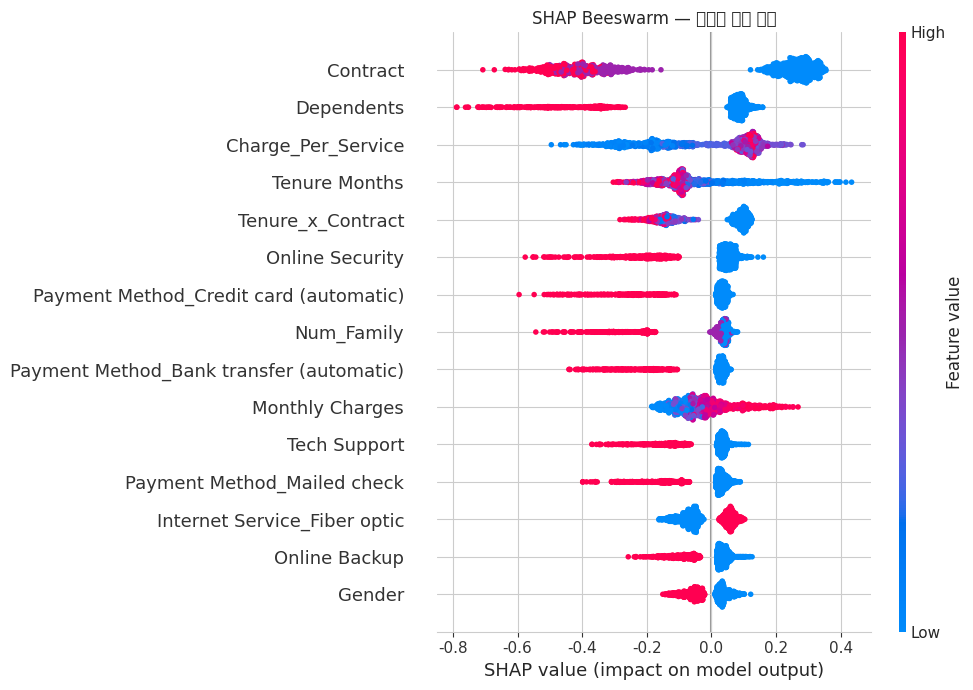

In [22]:
# ── 12-3. Beeswarm Plot (방향성 포함) ────────────────────────────────────
# 빨강(값 높음) → 이탈 확률 ↑ / 파랑(값 낮음) → 이탈 확률 ↓
# 예: Tenure Months 가 낮으면(파랑) SHAP 값 양수 → 이탈 기여
plt.figure()
shap.summary_plot(sv, X_test, show=False, max_display=15, plot_size=(10, 7))
plt.title('SHAP Beeswarm — 피처별 영향 방향', fontsize=12)
plt.tight_layout()
plt.show()

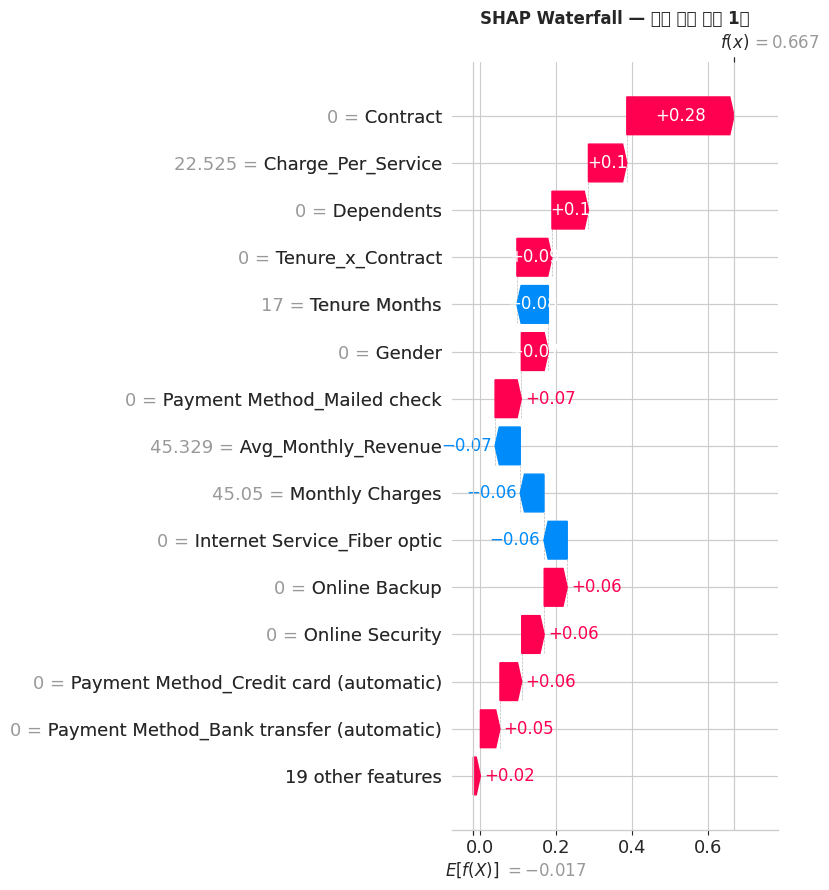


[분석 고객 주요 정보]
{'Tenure Months': 17.0, 'Monthly Charges': 45.05, 'Contract': 0.0, 'Num_Services': 1.0}


In [23]:
# ── 12-4. Waterfall Plot (개별 고객 예측 근거) ───────────────────────────
# 이탈 고객 1명을 뽑아 '왜 이탈 예측을 했는지' 개별 설명
# Streamlit 서비스에서 이 그래프를 고객별로 보여주는 것이 목표
churn_indices = np.where(y_test.values == 1)[0]
sample_idx    = churn_indices[0]

expected_val = (explainer.expected_value[1]
                if isinstance(explainer.expected_value, list)
                else explainer.expected_value)

explanation = shap.Explanation(
    values       = sv[sample_idx],
    base_values  = expected_val,
    data         = X_test.iloc[sample_idx].values,
    feature_names= X_test.columns.tolist()
)

plt.figure()
shap.waterfall_plot(explanation, show=False, max_display=15)
plt.title('SHAP Waterfall — 이탈 예측 고객 1명', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n[분석 고객 주요 정보]')
print(X_test.iloc[sample_idx][['Tenure Months', 'Monthly Charges',
                                'Contract', 'Num_Services']].to_dict())

## 14. 누수 변수 포함 vs 제외 성능 비교

> 누수 변수(Churn Score, CLTV)를 포함하면 AUC가 비정상적으로 높아짐을 검증.  
> 실전 배포 모델(누수 제외)과 비교해서 누수 영향을 정량화하는 셀.

In [25]:
# 누수 변수 포함 버전 — 원본 CSV를 다시 로드해서 재구성
df_raw_leak = pd.read_csv(DATA_PATH.replace('processed_data.csv', '') +
                          'Telco_customer_churn_-_Telco_Churn__2_.csv'
                          if 'processed' in DATA_PATH
                          else DATA_PATH.replace('processed_data', 'Telco_customer_churn_-_Telco_Churn__2_'))

# 원본 CSV 경로 직접 지정 (전처리 노트북의 FILE_PATH와 동일하게)
RAW_PATH = 'Telco_customer_churn_-_Telco_Churn__2_.csv'  # <- 필요시 수정
df_raw_leak = pd.read_csv(RAW_PATH)

df_raw_leak['Total Charges'] = pd.to_numeric(df_raw_leak['Total Charges'], errors='coerce').fillna(0)
df_raw_leak['Churn Value'] = df_raw_leak['Churn Value'].astype(int)

# 누수 포함 피처 구성 (Churn Score, CLTV 유지)
DROP_LEAK_COLS = [
    'CustomerID','Count','Country','State','City','Zip Code',
    'Lat Long','Latitude','Longitude',
    'Churn Reason','Churn Label',
]
df_leak = df_raw_leak.drop(columns=[c for c in DROP_LEAK_COLS if c in df_raw_leak.columns])

# 인코딩
binary_cols_l = ['Gender','Senior Citizen','Partner','Dependents','Phone Service','Paperless Billing']
binary_map_l  = {'Yes':1,'No':0,'Female':1,'Male':0}
for col in binary_cols_l:
    if col in df_leak.columns:
        df_leak[col] = df_leak[col].map(binary_map_l)

for col in ['Online Security','Online Backup','Device Protection',
            'Tech Support','Streaming TV','Streaming Movies']:
    if col in df_leak.columns:
        df_leak[col] = df_leak[col].replace('No internet service','No').map({'Yes':1,'No':0})
if 'Multiple Lines' in df_leak.columns:
    df_leak['Multiple Lines'] = df_leak['Multiple Lines'].replace('No phone service','No').map({'Yes':1,'No':0})
if 'Contract' in df_leak.columns:
    df_leak['Contract'] = df_leak['Contract'].map({'Month-to-month':0,'One year':1,'Two year':2})

df_leak = pd.get_dummies(df_leak, columns=['Payment Method','Internet Service'], drop_first=False)
bc2 = df_leak.select_dtypes(include='bool').columns.tolist()
df_leak[bc2] = df_leak[bc2].astype(int)

# 파생 피처
service_cols_l = ['Phone Service','Multiple Lines','Online Security','Online Backup',
                   'Device Protection','Tech Support','Streaming TV','Streaming Movies']
df_leak['Avg_Monthly_Revenue'] = np.where(
    df_leak['Tenure Months'] > 0,
    df_leak['Total Charges'] / df_leak['Tenure Months'],
    df_leak['Monthly Charges']
)
df_leak.drop(columns=['Total Charges'], inplace=True)
df_leak['Num_Services']       = df_leak[service_cols_l].sum(axis=1)
df_leak['Num_Family']         = df_leak['Partner'] + df_leak['Dependents']
df_leak['Charge_Per_Service'] = df_leak['Monthly Charges'] / (df_leak['Num_Services'] + 1)
df_leak['Senior_MtM']         = df_leak['Senior Citizen'] * (df_leak['Contract'] == 0).astype(int)
monthly_median_l = df_leak['Monthly Charges'].median()
df_leak['Is_New_High_Cost']   = ((df_leak['Tenure Months'] <= 6) & (df_leak['Monthly Charges'] > monthly_median_l)).astype(int)
df_leak['Charge_Delta']       = df_leak['Monthly Charges'] - df_leak['Avg_Monthly_Revenue']
df_leak['Value_Density']      = df_leak['Num_Services'] / (df_leak['Monthly Charges'] + 1)
df_leak['Fiber_Echeck']       = ((df_leak.get('Internet Service_Fiber optic', 0) == 1) &
                                  (df_leak.get('Payment Method_Electronic check', 0) == 1)).astype(int)
df_leak['Tenure_x_Contract']  = df_leak['Tenure Months'] * df_leak['Contract']

X_leak = df_leak.drop(columns=['Churn Value'], errors='ignore')
y_leak = df_leak['Churn Value']

X_tr_leak = X_leak.loc[X_train.index]
X_te_leak = X_leak.loc[X_test.index]
y_tr_leak  = y_leak.loc[X_train.index]
y_te_leak  = y_leak.loc[X_test.index]

smote_lk = SMOTE(random_state=SEED)
X_tr_lk_sm, y_tr_lk_sm = smote_lk.fit_resample(X_tr_leak, y_tr_leak)

model_leak = LGBMClassifier(**study.best_params, random_state=SEED, verbosity=-1, n_jobs=-1)
model_leak.fit(X_tr_lk_sm, y_tr_lk_sm)
auc_leak  = roc_auc_score(y_te_leak, model_leak.predict_proba(X_te_leak)[:, 1]) * 100
auc_clean = test_auc

print('=== LightGBM - 누수 포함 vs 제외 ===')
print(f'  누수 제외 (실전 모델) AUC: {auc_clean:.2f}%')
print(f'  누수 포함 (비교용)    AUC: {auc_leak:.2f}%')
print(f'  차이:                      {auc_leak - auc_clean:.2f}%')
if auc_leak - auc_clean > 3:
    print('  ** 3% 이상 급등 -> 데이터 누수 확인됨! Churn Score / CLTV 는 반드시 제외해야 함.')
else:
    print('  정상 범위')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['누수 제외\n(실전 모델)', '누수 포함\n(비교용)'],
              [auc_clean, auc_leak],
              color=['#42A5F5', '#EF5350'], edgecolor='white', width=0.4)
ax.set_ylabel('ROC-AUC (%)')
ax.set_title('누수 변수 포함/제외 AUC 비교', fontsize=13, fontweight='bold')
ax.set_ylim(50, 105)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}%', ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 15. 최종 요약

In [26]:
print('=' * 62)
print('  📋 Telco Churn 예측 모델 v4 — 최종 결과')
print('=' * 62)
print(f'  데이터셋           : IBM Telco Churn (7,043명)')
print(f'  이탈 비율          : {(y==1).mean()*100:.1f}% → K-Fold 내부 SMOTE 처리')
print(f'  피처 수            : {X.shape[1]}개 (파생 피처 10개 포함)')
print(f'  튜닝               : Optuna 300 trials / 5-Fold CV')
print()
print(f'  [LightGBM 단독]')
print(f'    CV AUC           : {study.best_value*100:.2f}%')
print(f'    Test AUC         : {test_auc:.2f}%')
print(f'    F1 (thr={best_threshold:.2f})   : {best_f1_opt:.2f}%')
print()
print(f'  [Stacking LGBM+XGB+RF → LR]')
print(f'    Test AUC         : {stk_auc:.2f}%')
print(f'    F1 (thr={best_thr_stk:.2f})   : {stk_f1_opt:.2f}%')
print(f'    AUC 향상         : {stk_auc - test_auc:+.2f}%')
print()
print('=' * 62)
print('  💡 v4 핵심 변경사항')
print('=' * 62)
print("""
  [Optuna]
  - trials: 100 → 300 (더 넓은 파라미터 탐색)

  [앙상블 방식 변경]
  - Soft Voting(단순 평균) → Stacking(메타러너 학습)
  - Base: LightGBM(Optuna 튜닝) + XGBoost + Random Forest
  - Meta: Logistic Regression (모델 신뢰도 가중치 학습)
  - OOF(Out-of-Fold) 방식 → 데이터 누수 없음

  [다음 단계]
  → passthrough=True 실험 (원본 피처도 메타 입력 추가)
  → 메타 모델을 LR → XGBoost로 교체 실험
  → Streamlit 앱: Stacking 모델로 교체
""")
print('=' * 62)


  📋 Telco Churn 예측 모델 v4 — 최종 결과
  데이터셋           : IBM Telco Churn (7,043명)
  이탈 비율          : 26.5% → K-Fold 내부 SMOTE 처리
  피처 수            : 33개 (파생 피처 10개 포함)
  튜닝               : Optuna 300 trials / 5-Fold CV

  [LightGBM 단독]
    CV AUC           : 85.59%
    Test AUC         : 84.33%
    F1 (thr=0.42)   : 63.59%

  [Stacking LGBM+XGB+RF → LR]
    Test AUC         : 84.10%
    F1 (thr=0.34)   : 64.13%
    AUC 향상         : -0.23%

  💡 v4 핵심 변경사항

  [Optuna]
  - trials: 100 → 300 (더 넓은 파라미터 탐색)

  [앙상블 방식 변경]
  - Soft Voting(단순 평균) → Stacking(메타러너 학습)
  - Base: LightGBM(Optuna 튜닝) + XGBoost + Random Forest
  - Meta: Logistic Regression (모델 신뢰도 가중치 학습)
  - OOF(Out-of-Fold) 방식 → 데이터 누수 없음

  [다음 단계]
  → passthrough=True 실험 (원본 피처도 메타 입력 추가)
  → 메타 모델을 LR → XGBoost로 교체 실험
  → Streamlit 앱: Stacking 모델로 교체

